In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv(r"D:\Cognifyz_Internship\Dataset\Dataset.csv")

print(df.head())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [3]:
features = df[
    ['Average Cost for two', 'Price range', 'Votes']
]

target = df['Aggregate rating']

print(features.head())

   Average Cost for two  Price range  Votes
0                  1100            3    314
1                  1200            3    591
2                  4000            4    270
3                  1500            4    365
4                  1500            4    229


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(7640, 3)
(1911, 3)


In [5]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression R2 Score:")
print(r2_score(y_test, linear_predictions))

Linear Regression R2 Score:
0.226781209472952


In [6]:
tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("Decision Tree R2 Score:")
print(r2_score(y_test, tree_predictions))

Decision Tree R2 Score:
0.9087081188192652


In [7]:
forest_model = RandomForestRegressor(random_state=42)

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)

print("Random Forest R2 Score:")
print(r2_score(y_test, forest_predictions))

Random Forest R2 Score:
0.9363212239144014


In [8]:
model_scores = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'R2 Score': [
        r2_score(y_test, linear_predictions),
        r2_score(y_test, tree_predictions),
        r2_score(y_test, forest_predictions)
    ]
})

print(model_scores)

               Model  R2 Score
0  Linear Regression  0.226781
1      Decision Tree  0.908708
2      Random Forest  0.936321


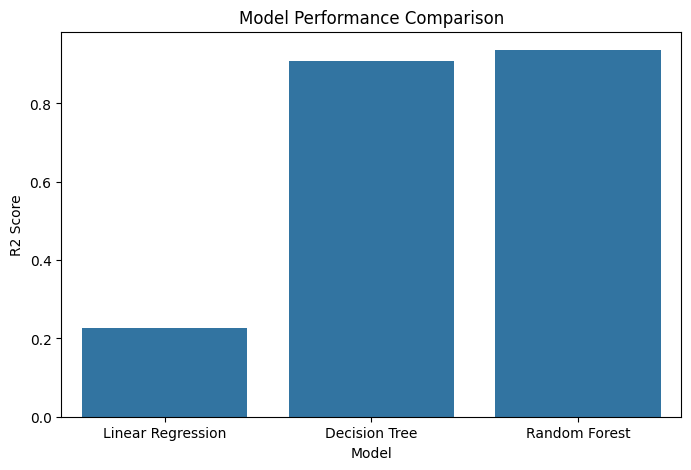

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=model_scores
)

plt.title("Model Performance Comparison")

plt.show()

## Conclusion

- Predictive modeling techniques were applied to predict restaurant ratings.
- Multiple machine learning algorithms were tested.
- Random Forest generally performed better compared to other models.
- Model comparison helped evaluate prediction accuracy effectively.
- Machine learning techniques provided valuable insights into restaurant rating prediction.